# Statistical Analysis of Rewards Data

This notebook analyzes the rewards and related metrics from the reinforcement learning training process.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [2]:
# Read the data
df = pd.read_csv('data/progress.csv')
print(f"Total episodes: {len(df)}")
df.head()

Total episodes: 3


,episode_num,mean_reward,std_reward,mean_reward_comfort_term,std_reward_comfort_term,mean_reward_energy_term,std_reward_energy_term,mean_comfort_penalty,std_comfort_penalty,mean_energy_penalty,...,mean_temperature_violation,std_temperature_violation,mean_power_demand,std_power_demand,cumulative_power_demand,comfort_violation_time(%),length(timesteps),time_elapsed(hours),terminated,truncated
0,1,-229.312928,236.162912,-0.004164,0.002147,-229.308764,236.163516,-8.327420,4.293942,-706.774308,...,8.327420,4.293942,706.774308,702.495208,4.315281e+07,100.0,61056,5088.0,False,True
1,2,-227.815812,236.134208,-0.004233,0.002236,-227.811579,236.134858,-8.465632,4.471130,-702.837650,...,8.465632,4.471130,702.837650,701.219316,4.291246e+07,100.0,61056,5088.0,False,True
2,3,-226.196721,234.922189,-0.004296,0.002245,-226.192424,234.922845,-8.592562,4.489356,-701.034884,...,8.592562,4.489356,701.034884,700.804133,4.280239e+07,100.0,61056,5088.0,False,True


## Basic Statistical Analysis

In [3]:
# Calculate basic statistics for key metrics
metrics = ['mean_reward', 'mean_reward_comfort_term', 'mean_reward_energy_term',
          'mean_comfort_penalty', 'mean_energy_penalty', 'mean_power_demand']

print("Basic Statistics:")
print("=================\n")
stats = df[metrics].describe()
stats

Basic Statistics:



,mean_reward,mean_reward_comfort_term,mean_reward_energy_term,mean_comfort_penalty,mean_energy_penalty,mean_power_demand
count,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
mean,-227.775153,-0.004231,-227.770922,-8.461871,-703.548947,703.548947
std,1.558501,0.000066,1.558568,0.132611,2.935082,2.935082
min,-229.312928,-0.004296,-229.308764,-8.592562,-706.774308,701.034884
25%,-228.564370,-0.004265,-228.560172,-8.529097,-704.805979,701.936267
50%,-227.815812,-0.004233,-227.811579,-8.465632,-702.837650,702.837650
75%,-227.006266,-0.004198,-227.002002,-8.396526,-701.936267,704.805979
max,-226.196721,-0.004164,-226.192424,-8.327420,-701.034884,706.774308


## Reward Trends Over Episodes

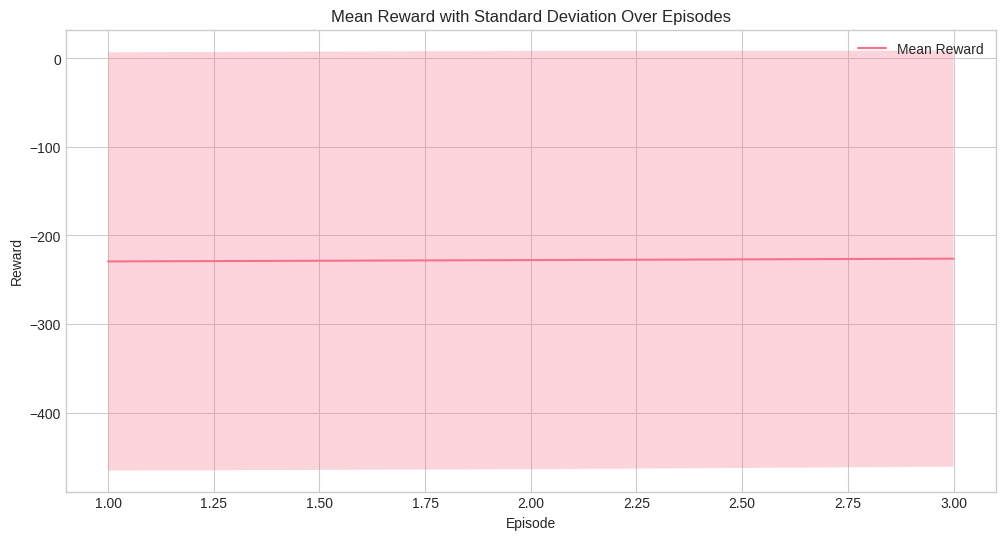

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(df['episode_num'], df['mean_reward'], label='Mean Reward')
plt.fill_between(df['episode_num'], 
                 df['mean_reward'] - df['std_reward'],
                 df['mean_reward'] + df['std_reward'],
                 alpha=0.3)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Mean Reward with Standard Deviation Over Episodes')
plt.legend()
plt.grid(True)
plt.show()

## Comfort vs Energy Trade-off Analysis

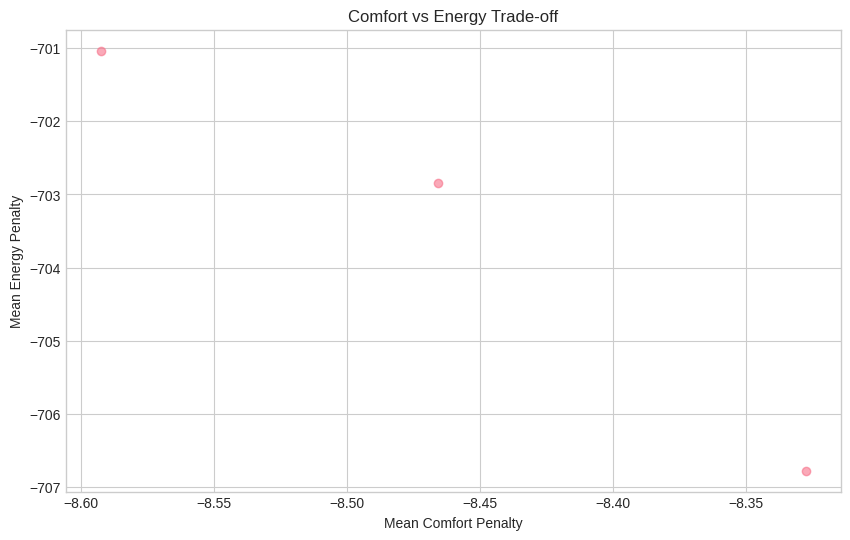

In [5]:
# Create a scatter plot of comfort vs energy penalties
plt.figure(figsize=(10, 6))
plt.scatter(df['mean_comfort_penalty'], df['mean_energy_penalty'], alpha=0.6)
plt.xlabel('Mean Comfort Penalty')
plt.ylabel('Mean Energy Penalty')
plt.title('Comfort vs Energy Trade-off')
plt.grid(True)
plt.show()

## Component-wise Reward Analysis

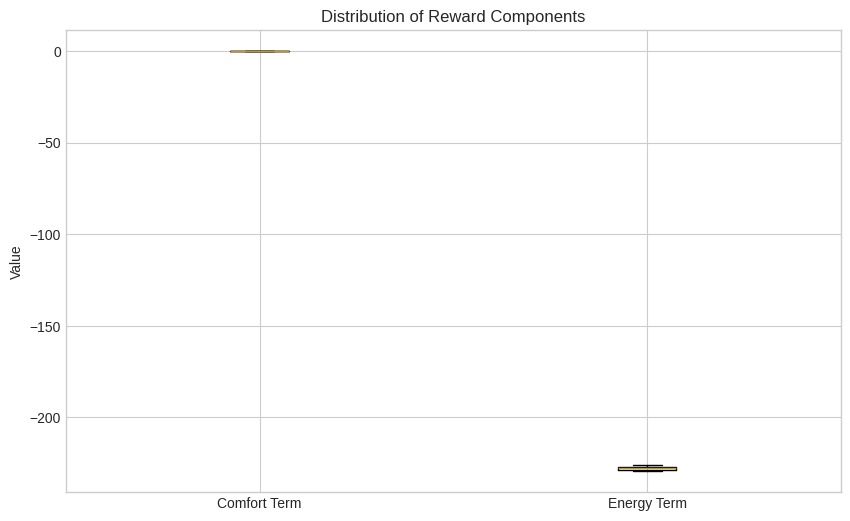

In [6]:
# Create box plots for different reward components
components = ['mean_reward_comfort_term', 'mean_reward_energy_term']
data = [df[component] for component in components]

plt.figure(figsize=(10, 6))
plt.boxplot(data, labels=['Comfort Term', 'Energy Term'])
plt.title('Distribution of Reward Components')
plt.ylabel('Value')
plt.grid(True)
plt.show()

## Power Demand Analysis

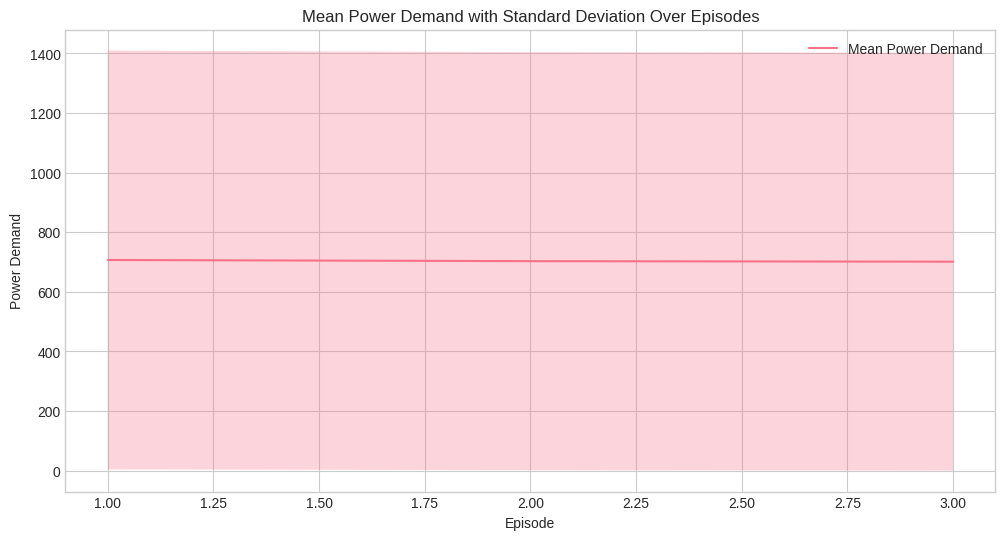

In [7]:
# Plot power demand over episodes
plt.figure(figsize=(12, 6))
plt.plot(df['episode_num'], df['mean_power_demand'], label='Mean Power Demand')
plt.fill_between(df['episode_num'],
                 df['mean_power_demand'] - df['std_power_demand'],
                 df['mean_power_demand'] + df['std_power_demand'],
                 alpha=0.3)
plt.xlabel('Episode')
plt.ylabel('Power Demand')
plt.title('Mean Power Demand with Standard Deviation Over Episodes')
plt.legend()
plt.grid(True)
plt.show()

## Correlation Analysis

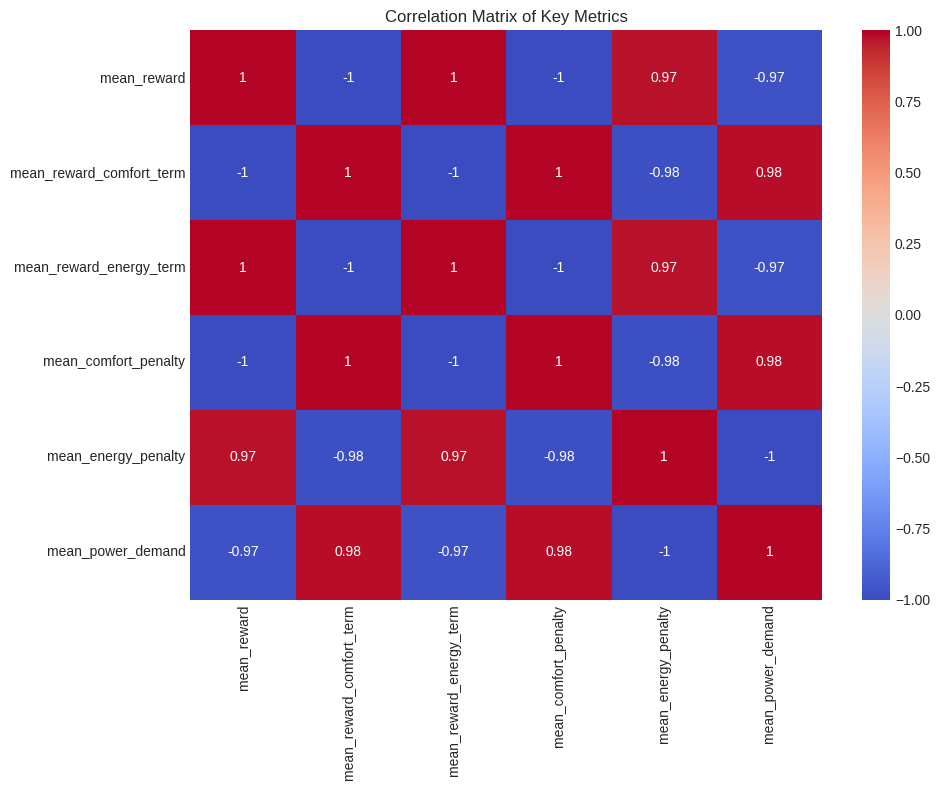

In [8]:
# Calculate correlation matrix for key metrics
correlation_metrics = ['mean_reward', 'mean_reward_comfort_term', 'mean_reward_energy_term',
                      'mean_comfort_penalty', 'mean_energy_penalty', 'mean_power_demand']
correlation_matrix = df[correlation_metrics].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Key Metrics')
plt.tight_layout()
plt.show()

## Summary Statistics

In [9]:
# Print summary of key findings
print("Summary Statistics:")
print("==================")
print(f"Average reward across all episodes: {df['mean_reward'].mean():.2f}")
print(f"Best episode reward: {df['mean_reward'].max():.2f}")
print(f"Worst episode reward: {df['mean_reward'].min():.2f}")
print(f"Average comfort violation time: {df['comfort_violation_time(%)'].mean():.2f}%")
print(f"Average power demand: {df['mean_power_demand'].mean():.2f}")

# Calculate improvement
first_reward = df.iloc[0]['mean_reward']
last_reward = df.iloc[-1]['mean_reward']
improvement = ((last_reward - first_reward) / abs(first_reward)) * 100
print(f"\nImprovement from first to last episode: {improvement:.2f}%")

Summary Statistics:
Average reward across all episodes: -227.78
Best episode reward: -226.20
Worst episode reward: -229.31
Average comfort violation time: 100.00%
Average power demand: 703.55

Improvement from first to last episode: 1.36%
